# Fake News Detection USing Dataset 3

In [42]:
import numpy as np
import pandas as pd
import re,string,unicodedata
import os

# NLP Libs
import nltk
from nltk.corpus import stopwords
#from nltk.stem.porter import PorterStemmer
from wordcloud import WordCloud,STOPWORDS
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize,sent_tokenize
#from bs4 import BeautifulSoup

from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

In [58]:
# Import our data

df = pd.read_csv("./dataset/WELFake_dataset/WELFake_Dataset.csv")

In [59]:
df.head(10)

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1
5,5,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1
6,6,DR BEN CARSON TARGETED BY THE IRS: “I never ha...,DR. BEN CARSON TELLS THE STORY OF WHAT HAPPENE...,1
7,7,HOUSE INTEL CHAIR On Trump-Russia Fake Story: ...,,1
8,8,Sports Bar Owner Bans NFL Games…Will Show Only...,"The owner of the Ringling Bar, located south o...",1
9,9,Latest Pipeline Leak Underscores Dangers Of Da...,"FILE – In this Sept. 15, 2005 file photo, the ...",1


In [60]:
# Invert the labels: 0 to 1 and 1 to 0
df['label'] = 1 - df['label']

In [61]:
df.head(10)

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,0
1,1,NaN,Did they post their votes for Hillary already?,0
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",0
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,1
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",0
5,5,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,0
6,6,DR BEN CARSON TARGETED BY THE IRS: “I never ha...,DR. BEN CARSON TELLS THE STORY OF WHAT HAPPENE...,0
7,7,HOUSE INTEL CHAIR On Trump-Russia Fake Story: ...,,0
8,8,Sports Bar Owner Bans NFL Games…Will Show Only...,"The owner of the Ringling Bar, located south o...",0
9,9,Latest Pipeline Leak Underscores Dangers Of Da...,"FILE – In this Sept. 15, 2005 file photo, the ...",0


In [62]:
df.shape

(72134, 4)

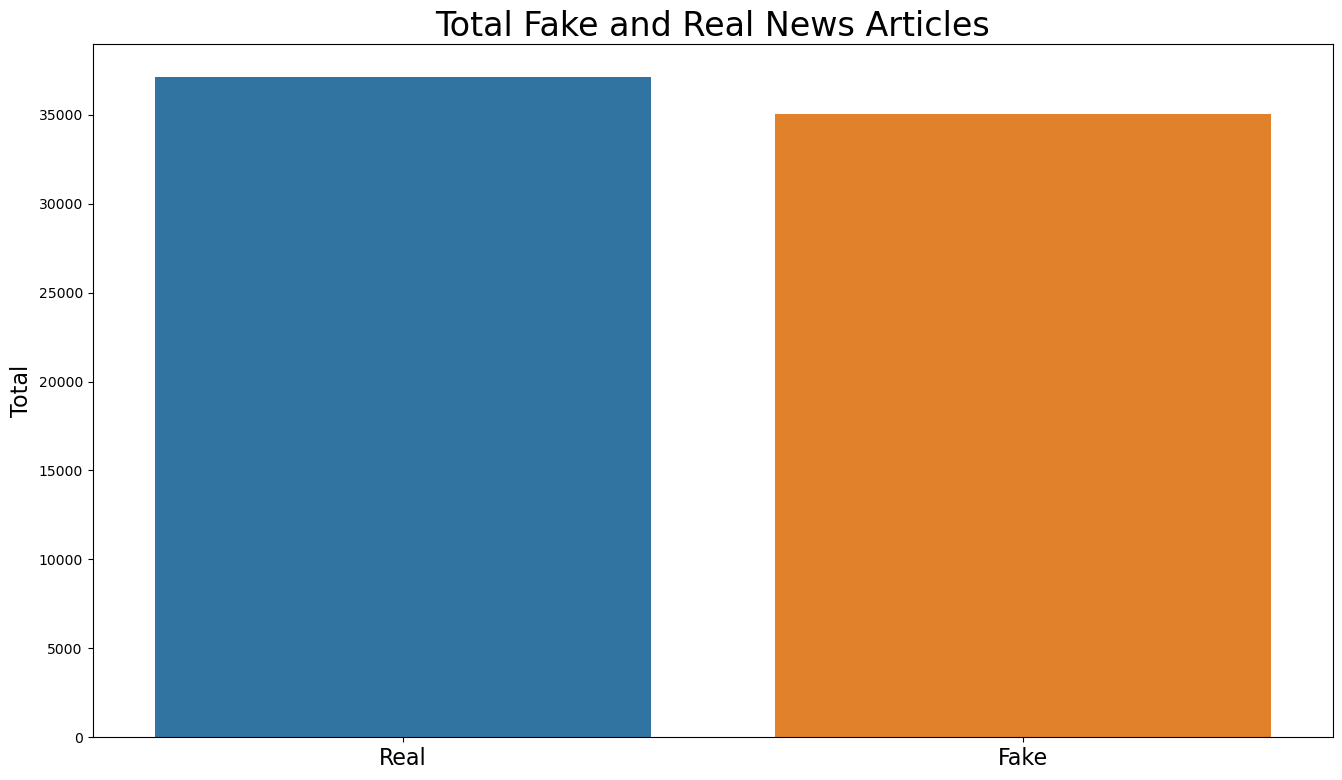

In [63]:
# Visualization Libs
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16,9))

#sns.countplot(df.label)
sns.countplot(data=df, x='label')

plt.title('Total Fake and Real News Articles', fontsize=24)
plt.ylabel('Total', fontsize=16)
plt.xlabel('')
plt.xticks([1, 0], ['Fake', 'Real'], fontsize=16)

plt.show()

In [64]:
df.columns

Index(['Unnamed: 0', 'title', 'text', 'label'], dtype='object')

In [65]:
print(df.isnull().sum())

Unnamed: 0      0
title         558
text           39
label           0
dtype: int64


In [66]:
df.sample(10)

,Unnamed: 0,title,text,label
52888,52888,WATCH: Bill Nye Predicts ‘Big Trouble’ After ...,Donald Trump s war on science drew a response ...,0
69103,69103,Bernie Sanders Derides Pick of Clinton Allies ...,Senator Bernie Sanders of Vermont is seeking t...,1
39295,39295,New Zealand National leader says will speak wi...,WELLINGTON (Reuters) - New Zealand National Pa...,1
10551,10551,France would not recognize unilateral Catalan ...,PARIS (Reuters) - France will not recognize Ca...,1
66931,66931,"Guess how leftists, millennials and ‘Black Liv...","Guess how leftists, millennials and Black Liv...",0
63935,63935,Clinton’s Campaign Chairman John Podesta Invit...,Support Us Clinton’s Campaign Chairman John Po...,0
59599,59599,Crushed Obama Aides React to Trump’s Decision ...,Former aides to former President Barack Obama ...,1
67865,67865,New Mexico Is Erasing Actual Science From The...,"Education standards, it seems, is now a term...",0
68436,68436,Bosnia making military progress in NATO bid - ...,SARAJEVO (Reuters) - Bosnia meets the military...,1
65341,65341,"Anton Yelchin, ‘Star Trek’ Actor, Dies at 27 -...","Anton Yelchin, who played the young incarnatio...",1


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  72134 non-null  int64 
 1   title       71576 non-null  object
 2   text        72095 non-null  object
 3   label       72134 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 2.2+ MB


In [68]:
df=df.fillna(' ')
# Now we'll create the Corpus that will be used in our NLP model

# This will create a single column with all the relevant text

df['total']=df['title']+' '+df['text']

In [69]:
print(df.isnull().sum())

Unnamed: 0    0
title         0
text          0
label         0
total         0
dtype: int64


In [70]:
df.head()

,Unnamed: 0,title,text,label,total
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...
1,1,,Did they post their votes for Hillary already?,0,Did they post their votes for Hillary already?
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",0,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,1,"Bobby Jindal, raised Hindu, uses story of Chri..."
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",0,SATAN 2: Russia unvelis an image of its terrif...


In [71]:
df = df.drop(['Unnamed: 0', 'title','text'],axis = 1)

In [72]:
df.head()

,label,total
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...
1,0,Did they post their votes for Hillary already?
2,0,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...
3,1,"Bobby Jindal, raised Hindu, uses story of Chri..."
4,0,SATAN 2: Russia unvelis an image of its terrif...


# Cleaning and preprocessing

In [73]:
stop_words = stopwords.words('english')
lemmatizer=WordNetLemmatizer()
for index,row in df.iterrows():
    filter_sentence = ''

    sentence = row['total']
    sentence = re.sub(r'[^\w\s]','',sentence) #cleaning
    words = nltk.word_tokenize(sentence) #tokenization
    words = [w.lower() for w in words if not w in stop_words]  #stopwords removal

    for word in words:
        filter_sentence = filter_sentence + ' ' + str(lemmatizer.lemmatize(word)).lower()

    df.loc[index,'total'] = filter_sentence

In [75]:
df.head()

,label,total
0,0,law enforcement on high alert following threa...
1,0,did post vote hillary already
2,0,unbelievable obamas attorney general say most...
3,1,bobby jindal raised hindu us story christian ...
4,0,satan 2 russia unvelis image terrifying new s...


In [74]:
df.to_csv("./dataset/WELFake_dataset/cleaned_dataset_2.csv")